In [4]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
COVARIATE = "temp" # temp or heat_index


INPUT_FILE = f"../data/{COVARIATE}/{COVARIATE}_ccf.csv"
OUTPUT_FILE = f"../plots/ccf/{COVARIATE}_ccf.png"

df = pd.read_csv(INPUT_FILE, index_col = 0)
df

,lags,Region.1,Region.2,Region.3,Region.4,Region.5,Region.6,Region.7,Region.8,Region.9,Region.10
1,-31,-0.027947,-0.017420,-0.002122,-0.012495,0.013237,0.027163,0.019562,-0.009501,-0.051065,0.013977
2,-30,-0.020610,-0.014086,-0.002654,-0.015200,0.002546,0.021549,0.011899,-0.011369,-0.045616,0.012356
3,-29,-0.019912,-0.016413,-0.001009,-0.010900,-0.011481,0.026438,-0.002171,-0.023916,-0.039574,0.014403
4,-28,-0.016381,-0.024317,-0.001661,-0.000241,-0.024721,0.026929,-0.013228,-0.019109,-0.033376,0.017873
5,-27,-0.016348,-0.018233,0.001987,0.006253,-0.036256,0.024262,-0.021817,-0.017790,-0.033730,0.017777
...,...,...,...,...,...,...,...,...,...,...,...
59,27,0.011500,-0.026003,-0.033889,0.018929,-0.038437,0.001628,-0.013135,-0.022074,-0.024037,0.023479
60,28,-0.002041,-0.034419,-0.050305,0.006699,-0.050367,-0.010352,-0.008453,-0.010541,-0.026616,0.022656
61,29,-0.042880,-0.062543,-0.062697,-0.004131,-0.059830,-0.027045,-0.009526,-0.010209,-0.033481,0.006431
62,30,-0.090561,-0.083243,-0.069014,-0.005551,-0.060128,-0.030182,-0.007564,-0.017117,-0.042039,-0.012393


OSError: [Errno 9] Bad file descriptor

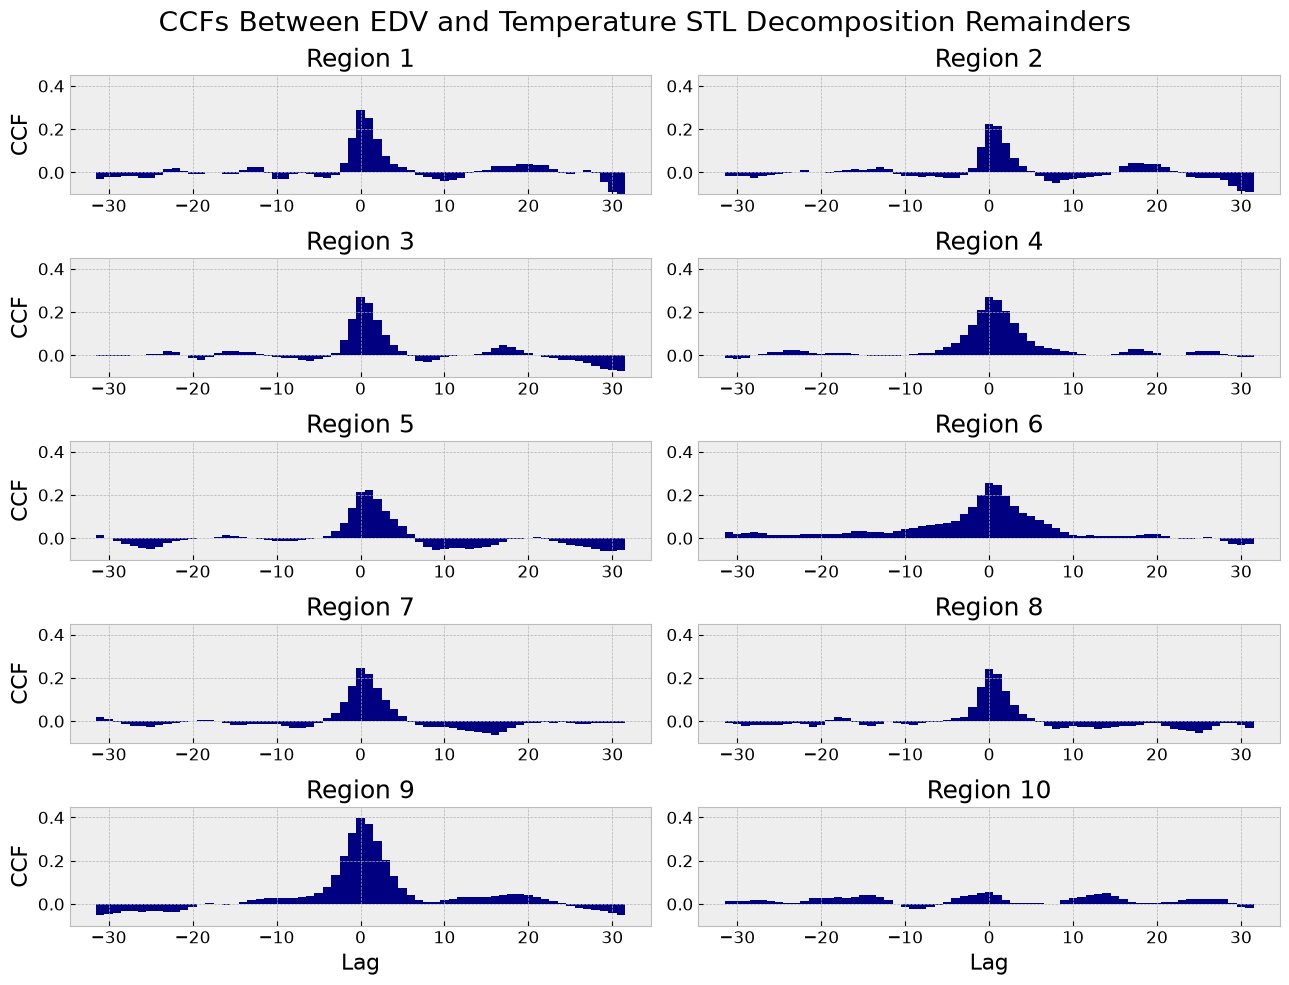

In [6]:
plt.style.use('bmh')
fig, axs = plt.subplots(5, 2, figsize = (13, 10))

covariate_for_title = "Temperature" if COVARIATE == "temp" else "Heat Index"
plt.suptitle(f"CCFs Between EDV and {covariate_for_title} STL Decomposition Remainders",fontsize = 20)

for i, region in enumerate(df.drop(columns = "lags").columns):
    col = i % 2
    row = i // 2
    ax = axs[row, col]

    ax.bar(df.lags, df[region], width = 1, color = "navy")
    ax.set_title(region.replace(".", " "), fontsize = 18)
    ax.set_ylim(-0.1, 0.45)
    if row == 4:
        ax.set_xlabel("Lag", fontsize = 16)
    if col == 0:
        ax.set_ylabel("CCF", fontsize = 16)

    ax.tick_params(axis='both', labelsize=12)

plt.tight_layout()

fig.savefig(OUTPUT_FILE, dpi = 300)